In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if 'google.colab' in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов

## Семинар 1. Пункт 1 — Работа с временными рядами в `pandas`

**Временной ряд** — это последовательность значений некоторой величины, упорядоченных во времени:
$y_{t_1}, y_{t_2}, \ldots, y_{t_n}$. От «обычной» таблицы его отличает то, что **порядок наблюдений и расстояния между моментами времени несут информацию** — их нельзя перемешивать.

`pandas` — базовый инструмент для работы с такими данными в Python: он умеет представлять моменты времени специальным типом `datetime`, индексировать ряд по времени, брать срезы по датам и менять частотность наблюдений.

**План пункта:**
1. Что важно помнить про время в данных.
2. Как из «сырых» транзакций получить временной ряд.
3. Индекс `datetime`: парсинг дат и типичные ловушки.
4. Периодичность и частотность, агрегация через `resample`.

## 1. Время в данных — о чём стоит помнить

Прежде чем работать с датами, полезно держать в голове несколько практических вещей — временные ряды особенно чувствительны к неаккуратностям в данных.

- **Часовые пояса.** Могут быть указаны или нет; влияют на дату. Желательно приводить всё к единому поясу (обычно UTC+0). Пояс источника может меняться (переход на летнее время и т.п.).
- **Как данные собирают.** Чаще всего они приходят из API строкой (в JSON нет типа «дата»); удобно складывать потоки в топики Kafka и агрегировать/пересемплировать перед записью в базу.
- **Где хранят.** RDBMS (PostgreSQL), колоночные БД (ClickHouse), специализированные TSDB (InfluxDB, TimescaleDB), объектное хранилище (S3), BigQuery и т.д. Выбор зависит от объёма и профиля нагрузки (часто пишем / редко читаем и наоборот).

Полезное чтение о ловушках со временем: [«Заблуждения программистов о времени»](https://habr.com/ru/articles/703360/).

Данные бывают двух видов: те, что изначально собирались как временные ряды (простой случай), и **транзакционные**, которые нужно предварительно агрегировать в ряд (сложнее). Разберём сразу второй случай.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (23, 9)

import warnings
warnings.filterwarnings("ignore")

## 2. От транзакций к временному ряду

Возьмём набор розничных транзакций: для каждого клиента — дата и сумма покупки. Это ещё не временной ряд, а «плоская» таблица событий.

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/Retail_Data_Transactions.csv")
data.head()

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78


Чтобы получить содержательный ряд, выберем клиента с самой длинной историей покупок.

In [3]:
data.groupby(by=["customer_id"]).count()["tran_amount"].idxmax()

'CS4424'

Построим временной ряд транзакций для клиента `CS4424`: сгруппируем суммы по клиенту и дате и оставим одного клиента.

In [4]:
sample = data.groupby(by=["customer_id", "trans_date"]).sum().loc["CS4424"]
# Изначально индекс -- в формате строк
sample.index

Index(['01-Dec-11', '01-Nov-12', '04-Jul-12', '04-Jul-13', '04-Oct-12',
       '04-Oct-14', '08-May-13', '10-Feb-14', '10-Mar-13', '10-Sep-11',
       '11-Apr-13', '11-Mar-13', '11-May-14', '13-Feb-13', '13-Mar-14',
       '15-Dec-14', '16-Mar-14', '16-May-13', '17-Apr-13', '17-Apr-14',
       '19-Aug-11', '19-Jan-15', '20-Nov-11', '24-Dec-14', '25-Aug-11',
       '25-Dec-13', '25-May-11', '26-Feb-14', '26-Mar-14', '27-Apr-13',
       '27-Jul-13', '28-Dec-12', '28-Dec-14', '28-Oct-14', '29-Apr-14',
       '29-Jan-12', '29-Nov-11', '30-Apr-13'],
      dtype='object', name='trans_date')

In [5]:
sample.head()

,tran_amount
trans_date,
01-Dec-11,47
01-Nov-12,99
04-Jul-12,36
04-Jul-13,57
04-Oct-12,97


## 3. Индекс `datetime`

Пока индекс — это просто строки, и pandas не умеет по ним «понимать» время. Переведём индекс в специальный тип `datetime`, характеризующий точку во времени, — после этого станут доступны срезы по датам, ресемплинг и извлечение компонент даты.

In [6]:
sample.index = pd.to_datetime(sample.index)
sample.index

DatetimeIndex(['2011-12-01', '2012-11-01', '2012-07-04', '2013-07-04',
               '2012-10-04', '2014-10-04', '2013-05-08', '2014-02-10',
               '2013-03-10', '2011-09-10', '2013-04-11', '2013-03-11',
               '2014-05-11', '2013-02-13', '2014-03-13', '2014-12-15',
               '2014-03-16', '2013-05-16', '2013-04-17', '2014-04-17',
               '2011-08-19', '2015-01-19', '2011-11-20', '2014-12-24',
               '2011-08-25', '2013-12-25', '2011-05-25', '2014-02-26',
               '2014-03-26', '2013-04-27', '2013-07-27', '2012-12-28',
               '2014-12-28', '2014-10-28', '2014-04-29', '2012-01-29',
               '2011-11-29', '2013-04-30'],
              dtype='datetime64[ns]', name='trans_date', freq=None)

In [7]:
sample.index[0]

Timestamp('2011-12-01 00:00:00')

### Парсинг дат: `pd.to_datetime`

Чаще всего `to_datetime` сам разбирает даты, но иногда ошибается. Если явно указать `format`, ошибок не будет — *«явное лучше неявного»*.

In [8]:
pd.to_datetime("12-11-2010 10:00", format="%d-%m-%Y %H:%M")

Timestamp('2010-11-12 10:00:00')

> ⚠️ **Ловушка.** При разборе числовой записи без формата по умолчанию используется **американский** порядок: месяц-день-год. Строка `"12-11-2010"` будет понята как 11 декабря, а не 12 ноября.

In [9]:
# день будет 11 (12 -- это месяц), а не 12
pd.to_datetime("12-11-2010 10:00").day

11

Чтобы этого избежать, используйте `dayfirst=True` (а лучше — всегда задавайте `format`).

In [10]:
pd.to_datetime("12-11-2010 10:00", dayfirst=True).day

12

При более явных форматах неоднозначности не возникает.

In [11]:
pd.to_datetime("24-Dec-14").day

24

### Компоненты даты в разных столбцах

Бывает, что части даты разнесены по столбцам. Если передать в `to_datetime` датафрейм со специальными именами столбцов, он соберёт даты сам.

- Обязательные столбцы: `year`, `month`, `day`.
- Опциональные: `hour`, `minute`, `second`, `millisecond`, `microsecond`, `nanosecond`.

In [12]:
df = pd.DataFrame(
    {"year": [2015, 2016], "month": [2, 3], "day": [4, 5], "hour": [2, 3]}
)
df

,year,month,day,hour
0,2015,2,4,2
1,2016,3,5,3


In [13]:
pd.to_datetime(df)

0   2015-02-04 02:00:00
1   2016-03-05 03:00:00
dtype: datetime64[ns]

Для невалидных / отсутствующих дат есть специальное значение `NaT` (Not a Timestamp).

In [14]:
pd.to_datetime([None])

DatetimeIndex(['NaT'], dtype='datetime64[ns]', freq=None)

## 4. Периодичность и частотность

Мы подошли к первой важной характеристике временного ряда — **периодичности**. Поставщик данных не всегда гарантирует, что наблюдения собраны через равные промежутки. Поэтому ряды делят на:
- **периодические** — наблюдения через регулярные промежутки;
- **непериодические (спорадические)** — как наши транзакции (покупки в произвольные дни).

**Частотность (frequency)** численно выражает число периодов между календарно эквивалентными точками: у годовых данных — 1, у месячных — 12, у дневных — 365/366.

Наши данные непериодичны. Перейти к периодическим можно **агрегацией** к более крупному периоду (`resample`) — но нужно выбрать функцию агрегации (сумма, среднее, ...) по смыслу задачи. Для спорадических данных это работает, только если наблюдений достаточно много: иначе появятся «дыры» — периоды без точек.

Справочники: [DateOffset-объекты](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#dateoffset-objects) и [`resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html).

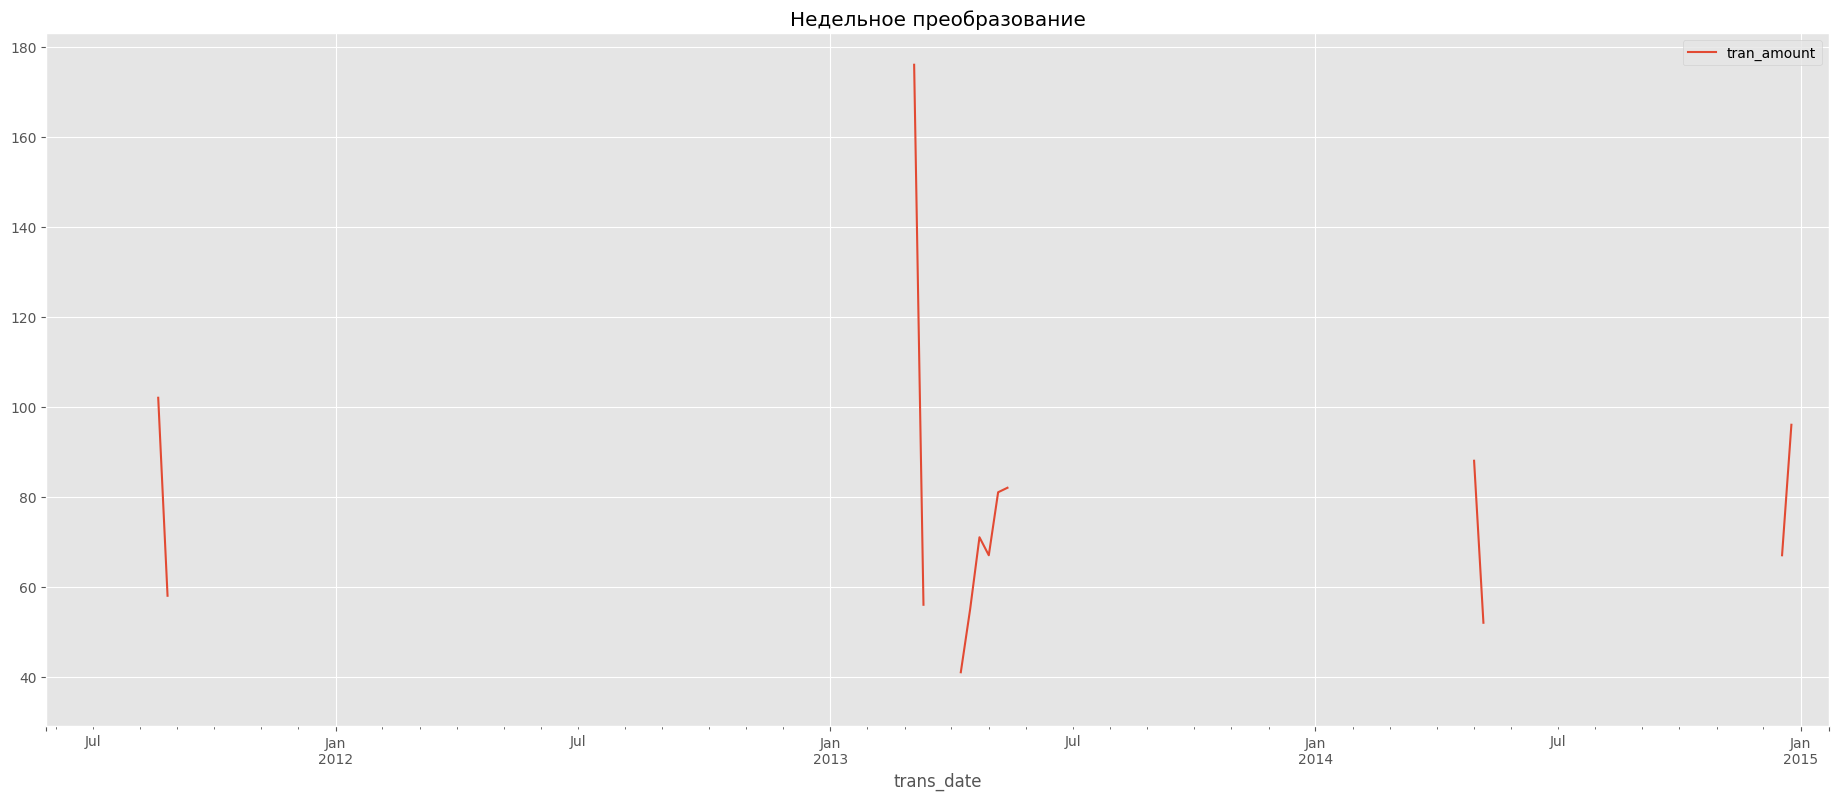

In [15]:
# Недельная агрегация. Функцию можно менять: например, sum() вместо mean().
# По умолчанию неделя привязана к воскресенью; начало можно сдвинуть: "W-MON".
sample.resample("W").mean().plot()
plt.title("Недельное преобразование");

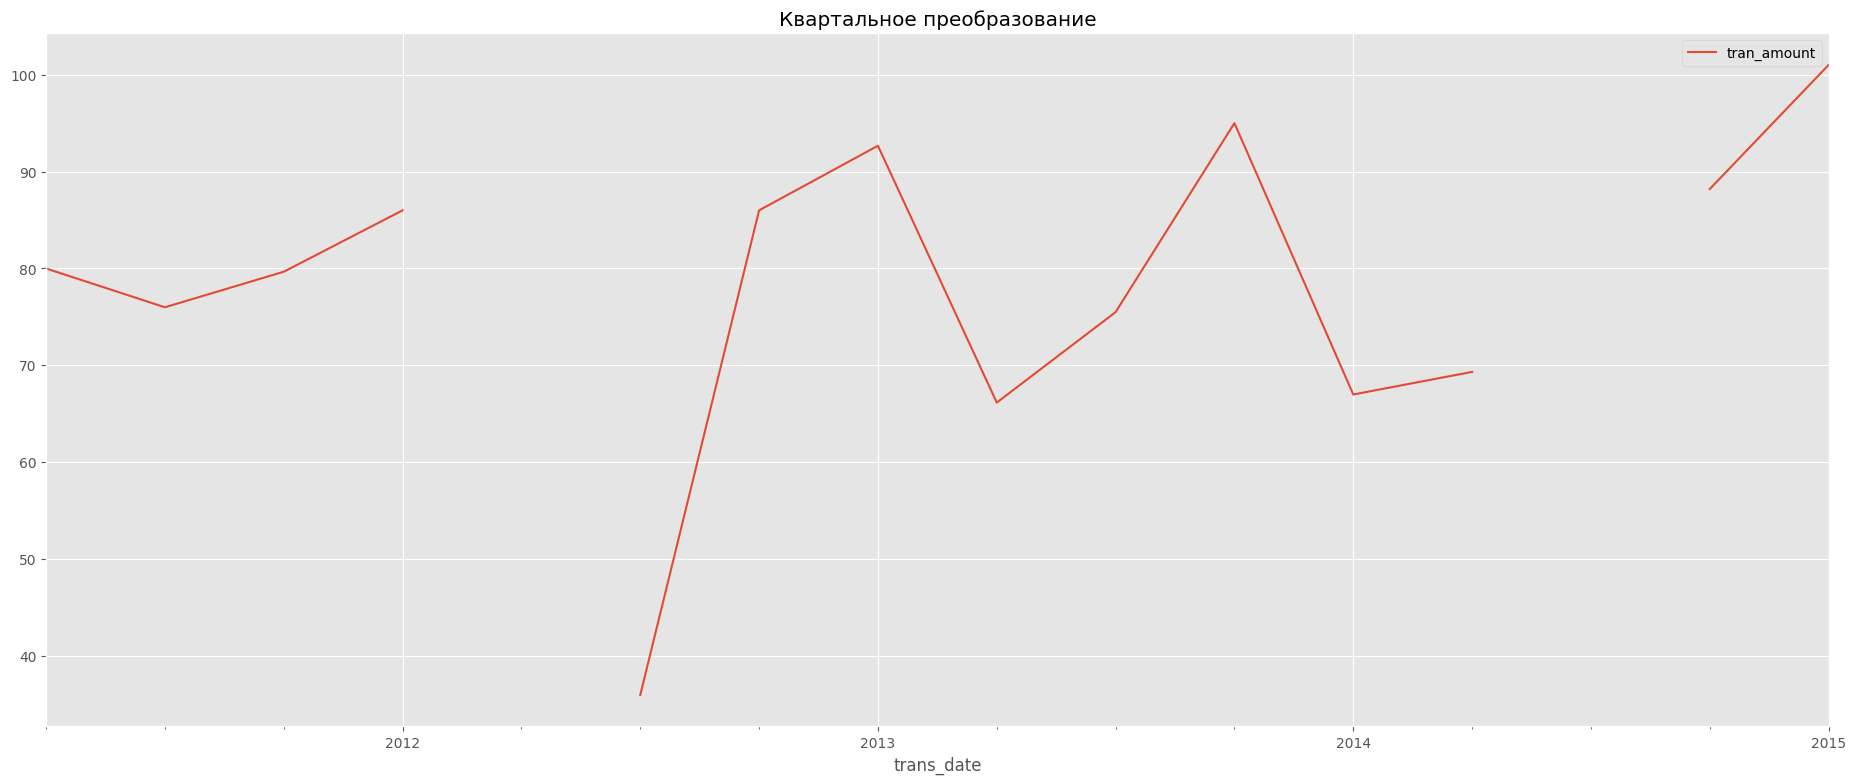

In [16]:
sample.resample("Q").mean().plot()
plt.title("Квартальное преобразование");

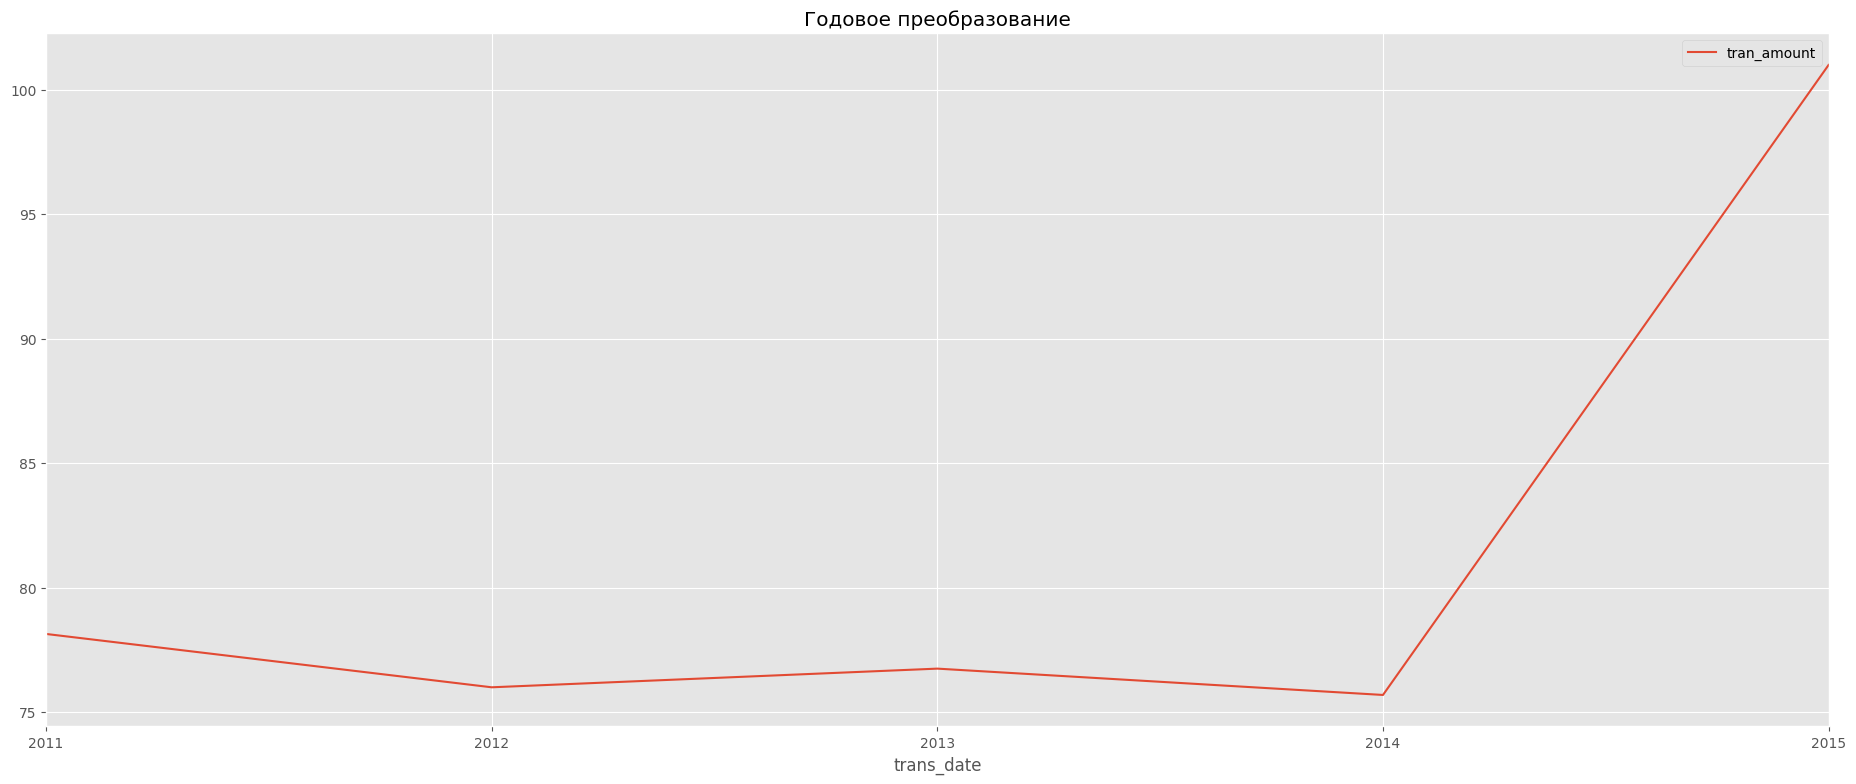

In [17]:
sample.resample("Y").mean().plot()
plt.title("Годовое преобразование");

Агрегация превратила непериодичные данные в периодичные, но точек осталось очень мало — пример скорее иллюстративный. Для по-настоящему спорадических данных лучше искать специальную модель, чем агрегировать.

Тот же приём применим и к **периодичным** данным — чтобы понизить гранулярность: например, почасовые продажи просуммировать до дневных, если наблюдений много.

## Итог пункта

- Временной ряд в pandas — это `Series`/`DataFrame` с индексом типа `datetime`.
- `pd.to_datetime` разбирает даты; во избежание ошибок задавайте `format` (или хотя бы `dayfirst`).
- Частотность — ключевая характеристика; `resample(...).agg()` меняет период и превращает спорадические данные в периодичные (с оговорками).

Дальше (**пункт 2**) посмотрим, какие вообще бывают **виды** временных рядов по структуре данных.